# Available data for results

In [1]:
from utils import simulation_analysis as sa
import pandas as pd
import numpy as np
import importlib


importlib.reload(sa)

available_simulations = sa.list_market_simulations()
display(available_simulations)

,sim_type,file_name,market_path,has_orders,has_executions,has_portfolios
0,classic,classic_coffee_ice_export_proxy,results\classic\classic_coffee_ice_export_prox...,True,True,False
1,classic,classic_colombia_coffee_fnc_spot,results\classic\classic_colombia_coffee_fnc_sp...,True,True,False
2,classic,classic_sp500_index_baseline,results\classic\classic_sp500_index_baseline_b...,True,True,False
3,classic,classic_sp500_index_baseline_local_backtest,results\classic\classic_sp500_index_baseline_l...,True,True,False
4,classic,classic_sp500_risk_off_shock,results\classic\classic_sp500_risk_off_shock_b...,True,True,False
5,classic,iter_1000_config,results\classic\iter_1000_config_base_results_...,False,False,False
6,classic,llm_miter_500_config,results\classic\llm_miter_500_config_base_resu...,True,True,False
7,llms,all_hybrid_sp500_index_baseline,results\llms\all_hybrid_sp500_index_baseline_b...,True,True,True
8,llms,contrarian_hybrid_sp500_index_baseline,results\llms\contrarian_hybrid_sp500_index_bas...,True,True,True
9,llms,defensive_hybrid_sp500_index_baseline,results\llms\defensive_hybrid_sp500_index_base...,True,False,True


In [2]:
def view_tables(macro,micro,architecture):
    print("Macro market validation")
    display(macro)
    
    print("Micro LLM-agent validation")
    display(micro)
    
    print("Architecture safeguard")
    display(architecture)

sp&500 default data

In [3]:
REAL_PRICE_COL = "S&P500"
REAL_DATE_COL = "Date"

CURRENT_AGENT_KNOWLEDGE = "2024-11-21"
HOLDOUT_STEPS = 20
COMPARISON_WARMUP_TICKS = 200
LLM_TYPE = "llms"  # "classic" or "llms"
Classic_TYPE = "classic"

## Fundamentalist results

c:\Users\alejo\Desktop\intro_la_inv\.venv\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


Analysis target: llms/all_hybrid_sp500_index_baseline
Market rows: 1200
Orders rows: 1200
Executions rows: 880
Portfolio rows: 180000
Comparison market rows after warmup trim: 1000


c:\Users\alejo\Desktop\intro_la_inv\.venv\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\alejo\Desktop\intro_la_inv\.venv\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\alejo\Desktop\intro_la_inv\.venv\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,value
n_observations,2.000000e+01
ticks_per_real_observation,5.257895e+01
mae,7.582450e+01
rmse,8.270075e+01
mape,1.257346e-02
price_correlation,-1.768572e-14
mean_error_bias,-5.203150e+01
median_absolute_error,8.151000e+01
nrmse_mean_price,1.373454e-02
nrmse_price_range,3.705397e-01


Macro market validation


,metric,value,principle
0,fat_tails_excess_kurtosis,0.0,Returns in real markets usually have fat tails...
1,volatility_clustering_abs_return_autocorr_1,NaN,Large price moves tend to cluster; positive au...
2,volatility_clustering_abs_return_autocorr_5,NaN,Checks whether volatility persistence remains ...
3,volatility_clustering_abs_return_autocorr_10,NaN,Checks whether volatility persistence remains ...
4,volume_volatility_correlation,NaN,Real markets often show higher volume during m...
5,ath_path_dependence_beta_h_mse_vs_real,NaN,Compares simulated and real beta_h; lower MSE ...
6,has_simulated_historic_maximum,True,Confirms whether the simulated path creates ne...
7,simulated_peak_price,7542.1597,Maximum simulated market price reached in the ...
8,simulated_peak_tick,0.0,Artificial tick where the simulated maximum ap...


Micro LLM-agent validation


,metric,value,principle
0,llm_orders,1200.000000,Number of observed LLM/FCL agent orders. NaN m...
1,llm_order_flow_imbalance,1.000000,(buy - sell) / total. Values near 0 mean balan...
2,ks_p_value_ath_nearness_buy_vs_sell,NaN,KS test comparing buy vs sell distributions ne...
3,mannwhitney_p_value_buy_vs_sell,NaN,Mann-Whitney U test for contextual buy/sell di...
4,portfolio_p01,0.401346,1st percentile of asset allocation proportion.
5,portfolio_p50,0.401346,Median asset allocation proportion.
6,portfolio_p99,0.401346,99th percentile of asset allocation proportion.
7,portfolio_stability_width_p99_minus_p01,0.000000,Smaller width suggests more stable portfolio a...
8,odean_proxy_pgr_minus_plr,0.986364,Proxy for disposition effect. Positive means m...


Architecture safeguard


,component,responsibility
0,LLM/FCL agent,Returns categorical trading intent and context...
1,Deterministic simulator,"Controls order pricing, sizing, matching, cash..."
2,Validation layer,Compares post-warmup simulated data with the r...


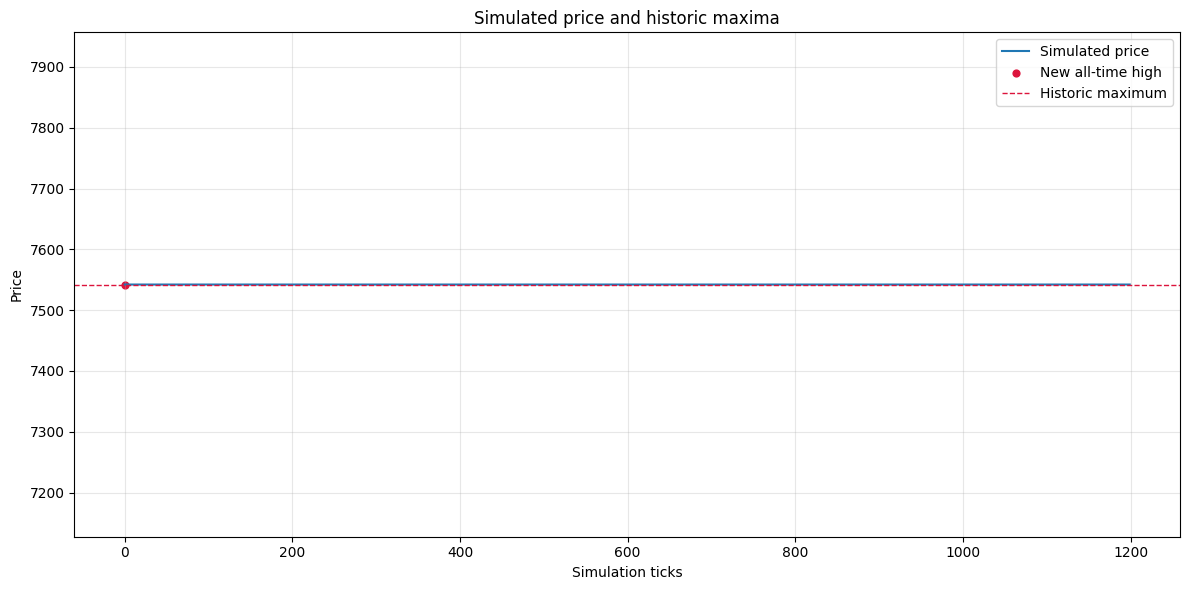

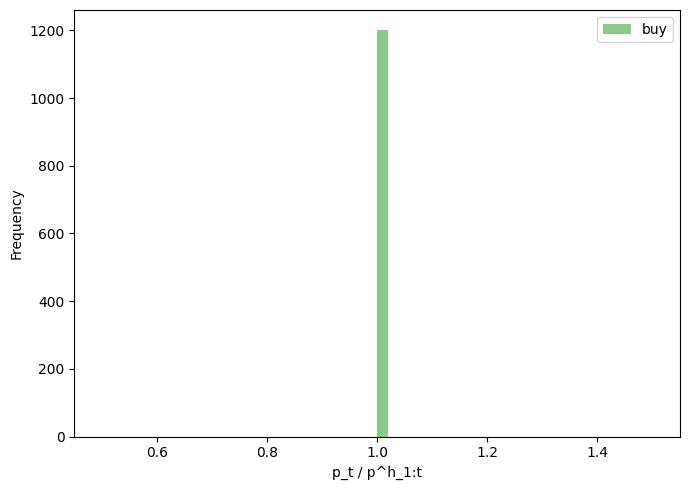

In [4]:

SIM_FILE_NAME = "all_hybrid_sp500_index_baseline"  # change this to your saved run name
REAL_DATA_PATH = "data/real/sp500_index.csv"

fun_paper_report, fun_artifacts = sa.analyze_simulation(
    sim_type=LLM_TYPE,
    file_name=SIM_FILE_NAME,
    rows_per_day=1,
    real_data_path=REAL_DATA_PATH,
    current_agent_knowledge=CURRENT_AGENT_KNOWLEDGE,
    holdout_steps=HOLDOUT_STEPS,
    real_price_col=REAL_PRICE_COL,
    real_date_col=REAL_DATE_COL,
    comparison_warmup_steps=COMPARISON_WARMUP_TICKS,
)
display(pd.DataFrame([fun_paper_report.get("validation_metrics", {})]).T.rename(columns={0: "value"}))


tables = sa.full_metric(fun_paper_report, fun_artifacts)
view_tables(tables["macro"], tables["micro"], tables["architecture"])

## Contrarian Results

Analysis target: llms/contrarian_hybrid_sp500_index_baseline
Market rows: 1200
Orders rows: 1200
Executions rows: 846
Portfolio rows: 180000
Comparison market rows after warmup trim: 1000


,value
n_observations,20.000000
ticks_per_real_observation,52.578947
mae,99.247989
rmse,110.416942
mape,0.016422
price_correlation,-0.238160
mean_error_bias,-82.093603
median_absolute_error,108.917167
nrmse_mean_price,0.018338
nrmse_price_range,0.494722


Macro market validation


,metric,value,principle
0,fat_tails_excess_kurtosis,18.61577,Returns in real markets usually have fat tails...
1,volatility_clustering_abs_return_autocorr_1,0.046582,Large price moves tend to cluster; positive au...
2,volatility_clustering_abs_return_autocorr_5,0.113187,Checks whether volatility persistence remains ...
3,volatility_clustering_abs_return_autocorr_10,0.069203,Checks whether volatility persistence remains ...
4,volume_volatility_correlation,0.60205,Real markets often show higher volume during m...
5,ath_path_dependence_beta_h_mse_vs_real,0.014534,Compares simulated and real beta_h; lower MSE ...
6,has_simulated_historic_maximum,True,Confirms whether the simulated path creates ne...
7,simulated_peak_price,7768.0,Maximum simulated market price reached in the ...
8,simulated_peak_tick,207.0,Artificial tick where the simulated maximum ap...


Micro LLM-agent validation


,metric,value,principle
0,llm_orders,1200.000000,Number of observed LLM/FCL agent orders. NaN m...
1,llm_order_flow_imbalance,0.081667,(buy - sell) / total. Values near 0 mean balan...
2,ks_p_value_ath_nearness_buy_vs_sell,0.000092,KS test comparing buy vs sell distributions ne...
3,mannwhitney_p_value_buy_vs_sell,0.535235,Mann-Whitney U test for contextual buy/sell di...
4,portfolio_p01,0.381990,1st percentile of asset allocation proportion.
5,portfolio_p50,0.402248,Median asset allocation proportion.
6,portfolio_p99,0.433521,99th percentile of asset allocation proportion.
7,portfolio_stability_width_p99_minus_p01,0.051531,Smaller width suggests more stable portfolio a...
8,odean_proxy_pgr_minus_plr,0.002387,Proxy for disposition effect. Positive means m...


Architecture safeguard


,component,responsibility
0,LLM/FCL agent,Returns categorical trading intent and context...
1,Deterministic simulator,"Controls order pricing, sizing, matching, cash..."
2,Validation layer,Compares post-warmup simulated data with the r...


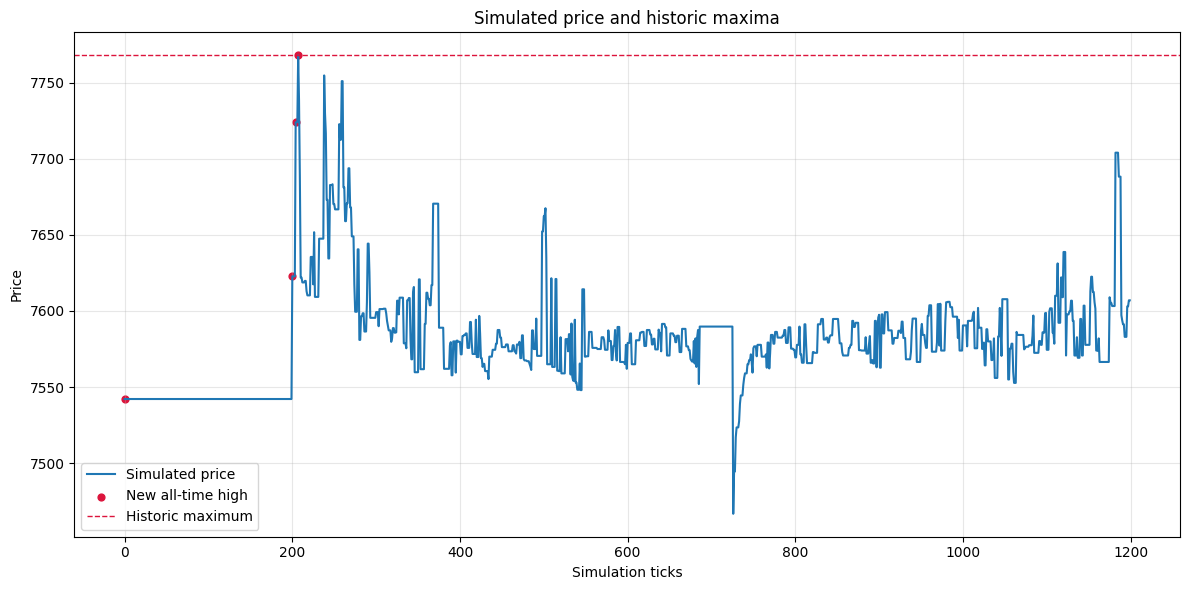

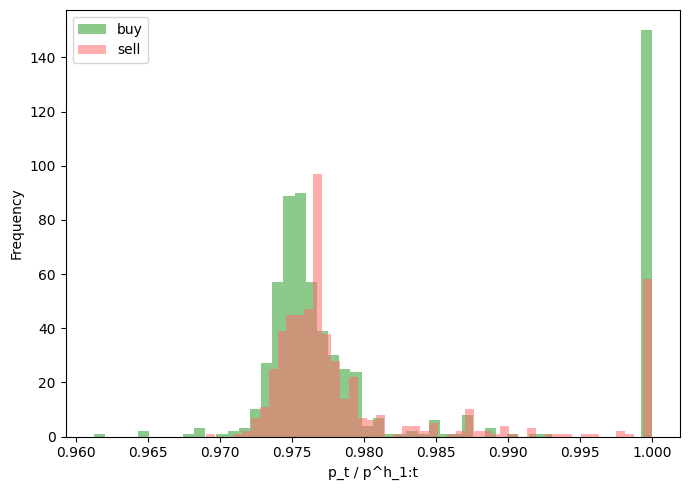

In [5]:

SIM_FILE_NAME = "contrarian_hybrid_sp500_index_baseline"  # change this to your saved run name
REAL_DATA_PATH = "data/real/sp500_index.csv"

fun_paper_report, fun_artifacts = sa.analyze_simulation(
    sim_type=LLM_TYPE,
    file_name=SIM_FILE_NAME,
    rows_per_day=1,
    real_data_path=REAL_DATA_PATH,
    current_agent_knowledge=CURRENT_AGENT_KNOWLEDGE,
    holdout_steps=HOLDOUT_STEPS,
    real_price_col=REAL_PRICE_COL,
    real_date_col=REAL_DATE_COL,
    comparison_warmup_steps=COMPARISON_WARMUP_TICKS,
)
display(pd.DataFrame([fun_paper_report.get("validation_metrics", {})]).T.rename(columns={0: "value"}))


tables = sa.full_metric(fun_paper_report, fun_artifacts)
view_tables(tables["macro"], tables["micro"], tables["architecture"])

## Follower Results

Analysis target: llms/follower_hybrid_sp500_index_baseline
Market rows: 1200
Orders rows: 1200
Executions rows: 0
Portfolio rows: 180000
Comparison market rows after warmup trim: 1000


c:\Users\alejo\Desktop\intro_la_inv\.venv\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


,value
n_observations,2.000000e+01
ticks_per_real_observation,5.257895e+01
mae,7.582450e+01
rmse,8.270075e+01
mape,1.257346e-02
price_correlation,-1.768572e-14
mean_error_bias,-5.203150e+01
median_absolute_error,8.151000e+01
nrmse_mean_price,1.373454e-02
nrmse_price_range,3.705397e-01


Macro market validation


,metric,value,principle
0,fat_tails_excess_kurtosis,0.0,Returns in real markets usually have fat tails...
1,volatility_clustering_abs_return_autocorr_1,NaN,Large price moves tend to cluster; positive au...
2,volatility_clustering_abs_return_autocorr_5,NaN,Checks whether volatility persistence remains ...
3,volatility_clustering_abs_return_autocorr_10,NaN,Checks whether volatility persistence remains ...
4,volume_volatility_correlation,NaN,Real markets often show higher volume during m...
5,ath_path_dependence_beta_h_mse_vs_real,NaN,Compares simulated and real beta_h; lower MSE ...
6,has_simulated_historic_maximum,True,Confirms whether the simulated path creates ne...
7,simulated_peak_price,7542.1597,Maximum simulated market price reached in the ...
8,simulated_peak_tick,0.0,Artificial tick where the simulated maximum ap...


Micro LLM-agent validation


,metric,value,principle
0,llm_orders,1200.000000,Number of observed LLM/FCL agent orders. NaN m...
1,llm_order_flow_imbalance,1.000000,(buy - sell) / total. Values near 0 mean balan...
2,ks_p_value_ath_nearness_buy_vs_sell,NaN,KS test comparing buy vs sell distributions ne...
3,mannwhitney_p_value_buy_vs_sell,NaN,Mann-Whitney U test for contextual buy/sell di...
4,portfolio_p01,0.401346,1st percentile of asset allocation proportion.
5,portfolio_p50,0.401346,Median asset allocation proportion.
6,portfolio_p99,0.401346,99th percentile of asset allocation proportion.
7,portfolio_stability_width_p99_minus_p01,0.000000,Smaller width suggests more stable portfolio a...
8,odean_proxy_pgr_minus_plr,NaN,Proxy for disposition effect. Positive means m...


Architecture safeguard


,component,responsibility
0,LLM/FCL agent,Returns categorical trading intent and context...
1,Deterministic simulator,"Controls order pricing, sizing, matching, cash..."
2,Validation layer,Compares post-warmup simulated data with the r...


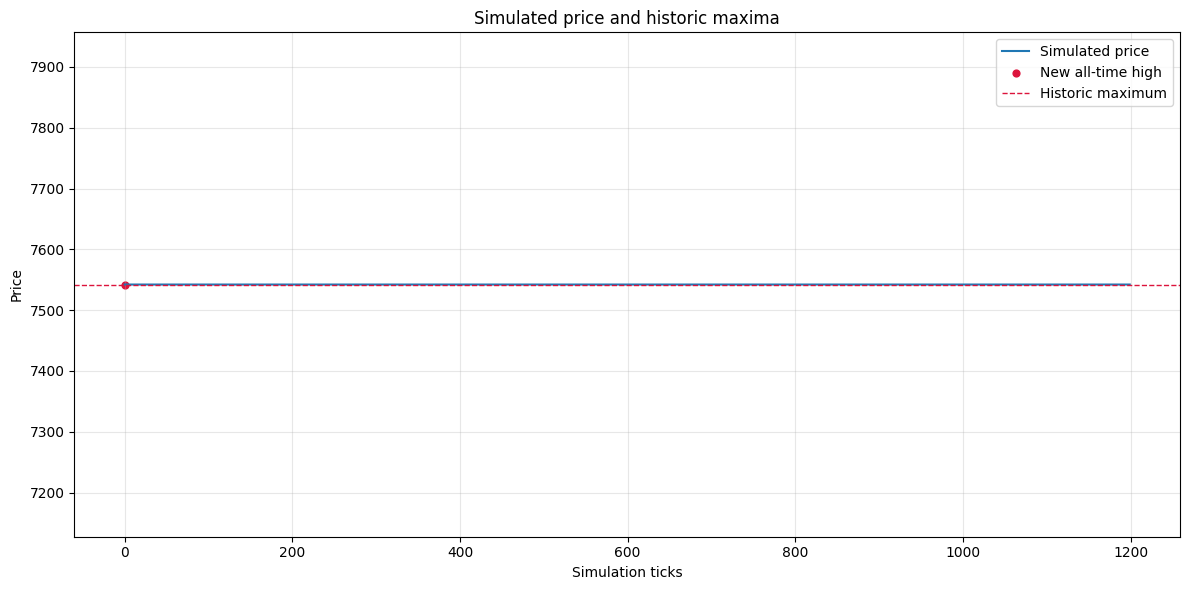

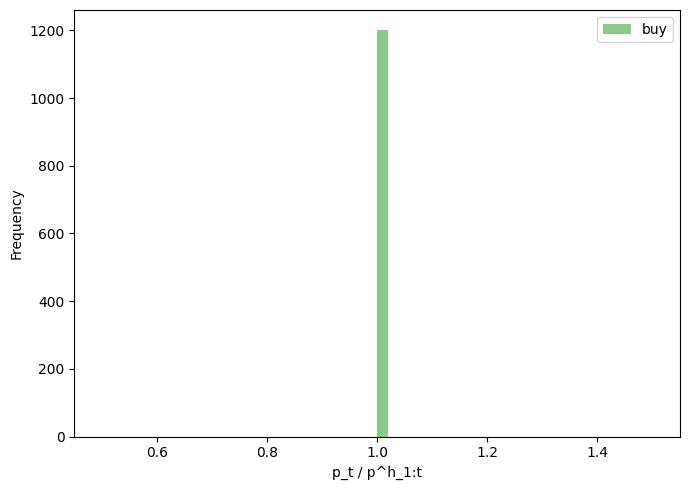

In [6]:

SIM_FILE_NAME = "follower_hybrid_sp500_index_baseline"  # change this to your saved run name
REAL_DATA_PATH = "data/real/sp500_index.csv"

fun_paper_report, fun_artifacts = sa.analyze_simulation(
    sim_type=LLM_TYPE,
    file_name=SIM_FILE_NAME,
    rows_per_day=1,
    real_data_path=REAL_DATA_PATH,
    current_agent_knowledge=CURRENT_AGENT_KNOWLEDGE,
    holdout_steps=HOLDOUT_STEPS,
    real_price_col=REAL_PRICE_COL,
    real_date_col=REAL_DATE_COL,
    comparison_warmup_steps=COMPARISON_WARMUP_TICKS,
)
display(pd.DataFrame([fun_paper_report.get("validation_metrics", {})]).T.rename(columns={0: "value"}))


tables = sa.full_metric(fun_paper_report, fun_artifacts)
view_tables(tables["macro"], tables["micro"], tables["architecture"])

## Defensive

Analysis target: llms/defensive_hybrid_sp500_index_baseline
Market rows: 1200
Orders rows: 1200
Executions rows: 0
Portfolio rows: 180000
Comparison market rows after warmup trim: 1000


c:\Users\alejo\Desktop\intro_la_inv\.venv\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


,value
n_observations,2.000000e+01
ticks_per_real_observation,5.257895e+01
mae,7.582450e+01
rmse,8.270075e+01
mape,1.257346e-02
price_correlation,-1.768572e-14
mean_error_bias,-5.203150e+01
median_absolute_error,8.151000e+01
nrmse_mean_price,1.373454e-02
nrmse_price_range,3.705397e-01


Macro market validation


,metric,value,principle
0,fat_tails_excess_kurtosis,0.0,Returns in real markets usually have fat tails...
1,volatility_clustering_abs_return_autocorr_1,NaN,Large price moves tend to cluster; positive au...
2,volatility_clustering_abs_return_autocorr_5,NaN,Checks whether volatility persistence remains ...
3,volatility_clustering_abs_return_autocorr_10,NaN,Checks whether volatility persistence remains ...
4,volume_volatility_correlation,NaN,Real markets often show higher volume during m...
5,ath_path_dependence_beta_h_mse_vs_real,NaN,Compares simulated and real beta_h; lower MSE ...
6,has_simulated_historic_maximum,True,Confirms whether the simulated path creates ne...
7,simulated_peak_price,7542.1597,Maximum simulated market price reached in the ...
8,simulated_peak_tick,0.0,Artificial tick where the simulated maximum ap...


Micro LLM-agent validation


,metric,value,principle
0,llm_orders,1200.000000,Number of observed LLM/FCL agent orders. NaN m...
1,llm_order_flow_imbalance,-1.000000,(buy - sell) / total. Values near 0 mean balan...
2,ks_p_value_ath_nearness_buy_vs_sell,NaN,KS test comparing buy vs sell distributions ne...
3,mannwhitney_p_value_buy_vs_sell,NaN,Mann-Whitney U test for contextual buy/sell di...
4,portfolio_p01,0.401346,1st percentile of asset allocation proportion.
5,portfolio_p50,0.401346,Median asset allocation proportion.
6,portfolio_p99,0.401346,99th percentile of asset allocation proportion.
7,portfolio_stability_width_p99_minus_p01,0.000000,Smaller width suggests more stable portfolio a...
8,odean_proxy_pgr_minus_plr,NaN,Proxy for disposition effect. Positive means m...


Architecture safeguard


,component,responsibility
0,LLM/FCL agent,Returns categorical trading intent and context...
1,Deterministic simulator,"Controls order pricing, sizing, matching, cash..."
2,Validation layer,Compares post-warmup simulated data with the r...


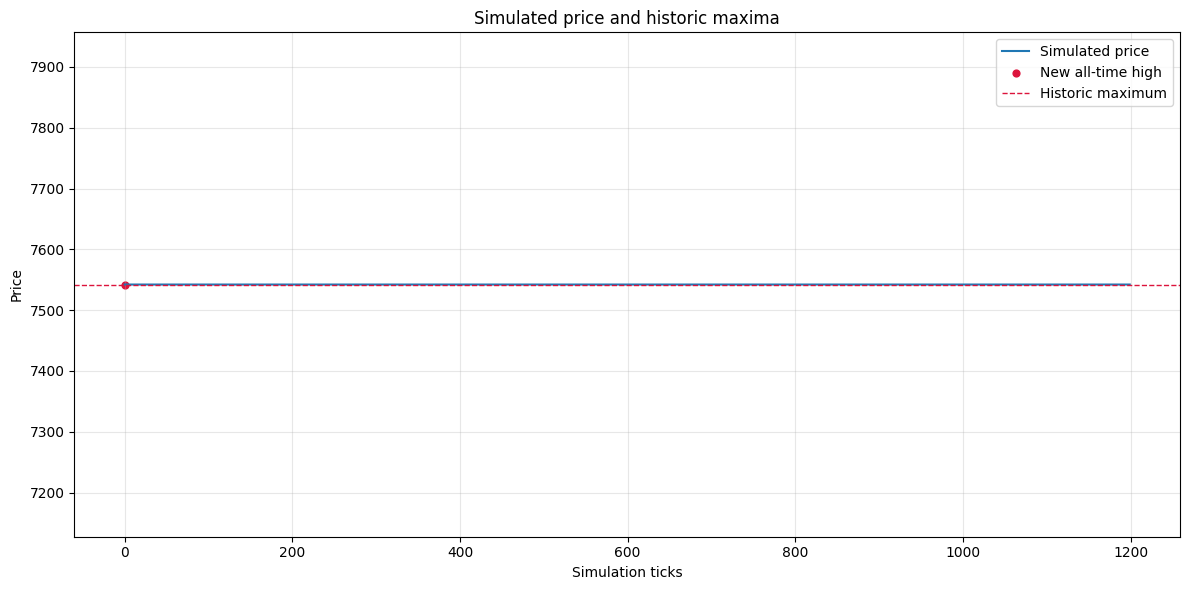

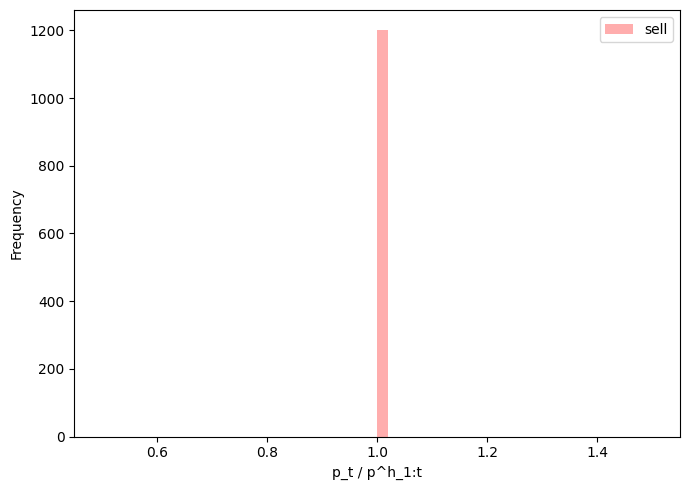

In [7]:

SIM_FILE_NAME = "defensive_hybrid_sp500_index_baseline"  # change this to your saved run name
REAL_DATA_PATH = "data/real/sp500_index.csv"

fun_paper_report, fun_artifacts = sa.analyze_simulation(
    sim_type=LLM_TYPE,
    file_name=SIM_FILE_NAME,
    rows_per_day=1,
    real_data_path=REAL_DATA_PATH,
    current_agent_knowledge=CURRENT_AGENT_KNOWLEDGE,
    holdout_steps=HOLDOUT_STEPS,
    real_price_col=REAL_PRICE_COL,
    real_date_col=REAL_DATE_COL,
    comparison_warmup_steps=COMPARISON_WARMUP_TICKS,
)
display(pd.DataFrame([fun_paper_report.get("validation_metrics", {})]).T.rename(columns={0: "value"}))


tables = sa.full_metric(fun_paper_report, fun_artifacts)
view_tables(tables["macro"], tables["micro"], tables["architecture"])

## Explorer

In [ ]:

SIM_FILE_NAME = "explorer_hybrid_sp500_index_baseline"  # change this to your saved run name
REAL_DATA_PATH = "data/real/sp500_index.csv"

fun_paper_report, fun_artifacts = sa.analyze_simulation(
    sim_type=LLM_TYPE,
    file_name=SIM_FILE_NAME,
    rows_per_day=1,
    real_data_path=REAL_DATA_PATH,
    current_agent_knowledge=CURRENT_AGENT_KNOWLEDGE,
    holdout_steps=HOLDOUT_STEPS,
    real_price_col=REAL_PRICE_COL,
    real_date_col=REAL_DATE_COL,
    comparison_warmup_steps=COMPARISON_WARMUP_TICKS,
)
display(pd.DataFrame([fun_paper_report.get("validation_metrics", {})]).T.rename(columns={0: "value"}))


tables = sa.full_metric(fun_paper_report, fun_artifacts)
view_tables(tables["macro"], tables["micro"], tables["architecture"])

## Equal distribution Results

from utils import simulation_analysis as sa
import pandas as pd
import numpy as np
import importlib

importlib.reload(sa)

available_simulations = sa.list_market_simulations()
display(available_simulations)

Analysis target: classic/classic_sp500_index_baseline
Market rows: 1200
Orders rows: 1200
Executions rows: 834
Portfolio rows: 0
Comparison market rows after warmup trim: 1000


,value
n_observations,20.000000
ticks_per_real_observation,52.578947
mae,68.915205
rmse,76.888563
mape,0.011432
price_correlation,0.255128
mean_error_bias,-45.082783
median_absolute_error,77.289420
nrmse_mean_price,0.012769
nrmse_price_range,0.344498


(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='p_t / p^h_1:t', ylabel='Frequency'>,
 {'n_buy': 639.0,
  'n_sell': 561.0,
  'buy_mean_nearness': 0.991225028946953,
  'sell_mean_nearness': 0.9912189095186097,
  'buy_at_exact_high': 147.0,
  'sell_at_exact_high': 78.0,
  'ks_p_value': 0.01304933477752847,
  'mannwhitney_p_value': 0.8325166838833991})

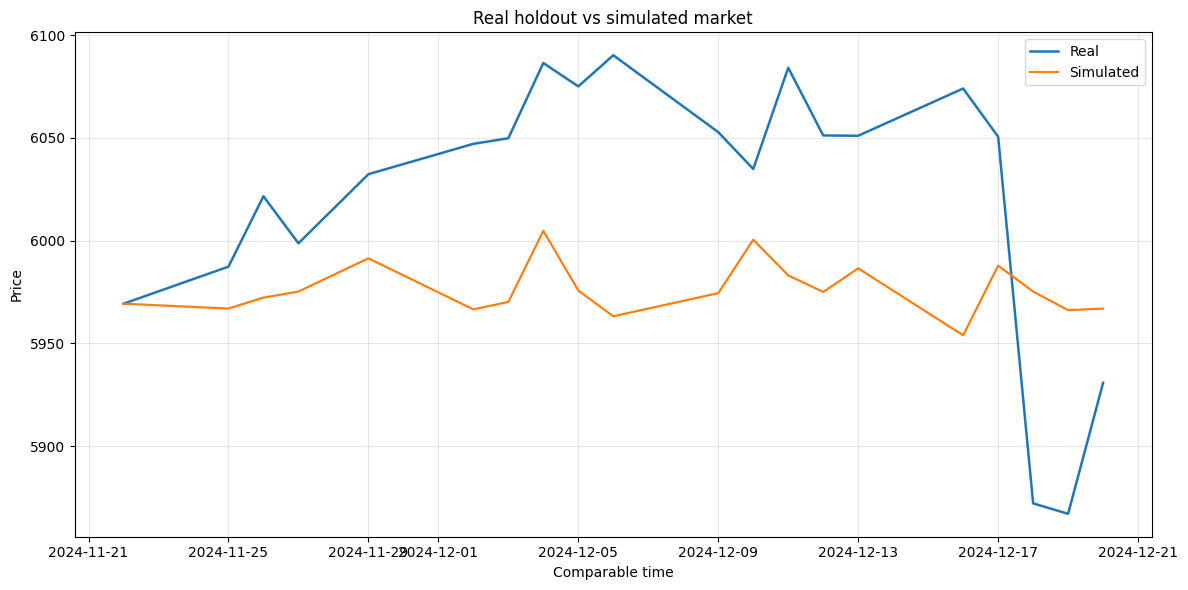

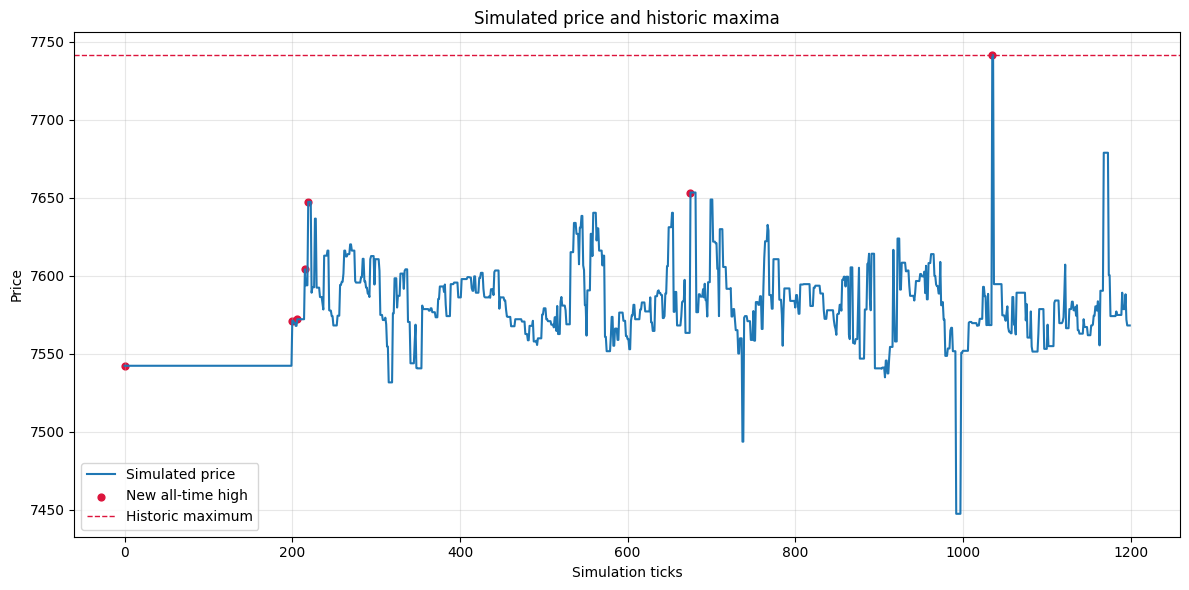

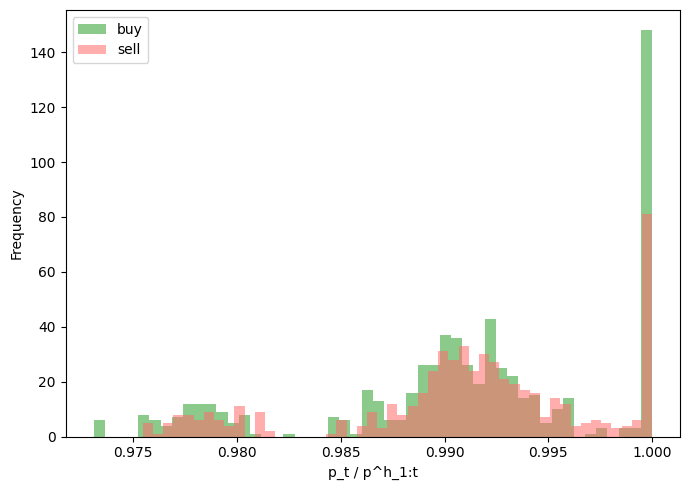

In [9]:
SIM_TYPE = "classic"  # "classic" or "llms"
SIM_FILE_NAME = "classic_sp500_index_baseline"  # change this to your saved run name

REAL_DATA_PATH = "data/real/sp500_index.csv"
REAL_PRICE_COL = "S&P500"
REAL_DATE_COL = "Date"

CURRENT_AGENT_KNOWLEDGE = "2024-11-21"
HOLDOUT_STEPS = 20
COMPARISON_WARMUP_TICKS = 200

classic_paper_report, classic_artifacts = sa.analyze_simulation(
    sim_type=SIM_TYPE,
    file_name=SIM_FILE_NAME,
    rows_per_day=1,
    real_data_path=REAL_DATA_PATH,
    current_agent_knowledge=CURRENT_AGENT_KNOWLEDGE,
    holdout_steps=HOLDOUT_STEPS,
    real_price_col=REAL_PRICE_COL,
    real_date_col=REAL_DATE_COL,
    comparison_warmup_steps=COMPARISON_WARMUP_TICKS,
)

display(pd.DataFrame([classic_paper_report.get("validation_metrics", {})]).T.rename(columns={0: "value"}))
sa.plot_real_vs_simulated(
    classic_paper_report["real_vs_simulated"]["aligned"],
    title="Real holdout vs simulated market"
)

sa.plot_simulated_historic_maximum(
    classic_artifacts["market"],
    price_col="market_price"
)

sa.plot_all_time_high_nearness_histogram(
    classic_paper_report["order_nearness"]
)

### Hybrid simulation metrics

In [10]:
SIM_TYPE = "llms"  # "classic" or "llms"
SIM_FILE_NAME = "hybrid_sp500_index_baseline"  # change this to your saved run name
REAL_DATA_PATH = "data/real/sp500_index.csv"
REAL_PRICE_COL = "S&P500"
REAL_DATE_COL = "Date"

CURRENT_AGENT_KNOWLEDGE = "2024-11-21"
HOLDOUT_STEPS = 20
COMPARISON_WARMUP_TICKS = 200

llm_paper_report, llm_artifacts = sa.analyze_simulation(
    sim_type=SIM_TYPE,
    file_name=SIM_FILE_NAME,
    rows_per_day=1,
    real_data_path=REAL_DATA_PATH,
    current_agent_knowledge=CURRENT_AGENT_KNOWLEDGE,
    holdout_steps=HOLDOUT_STEPS,
    real_price_col=REAL_PRICE_COL,
    real_date_col=REAL_DATE_COL,
    comparison_warmup_steps=COMPARISON_WARMUP_TICKS,
)

display(pd.DataFrame([llm_paper_report.get("validation_metrics", {})]).T.rename(columns={0: "value"}))

Analysis target: llms/hybrid_sp500_index_baseline
Market rows: 700
Orders rows: 700
Executions rows: 466
Portfolio rows: 350000
Comparison market rows after warmup trim: 500


,value
n_observations,20.000000
ticks_per_real_observation,26.263158
mae,59.330536
rmse,77.068016
mape,0.009918
price_correlation,-0.231041
mean_error_bias,4.841403
median_absolute_error,51.127640
nrmse_mean_price,0.012799
nrmse_price_range,0.345302


(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='p_t / p^h_1:t', ylabel='Frequency'>,
 {'n_buy': 436.0,
  'n_sell': 264.0,
  'buy_mean_nearness': 0.992036039989584,
  'sell_mean_nearness': 0.9898164675326626,
  'buy_at_exact_high': 189.0,
  'sell_at_exact_high': 47.0,
  'ks_p_value': 6.219404996790626e-10,
  'mannwhitney_p_value': 5.293047773994798e-05})

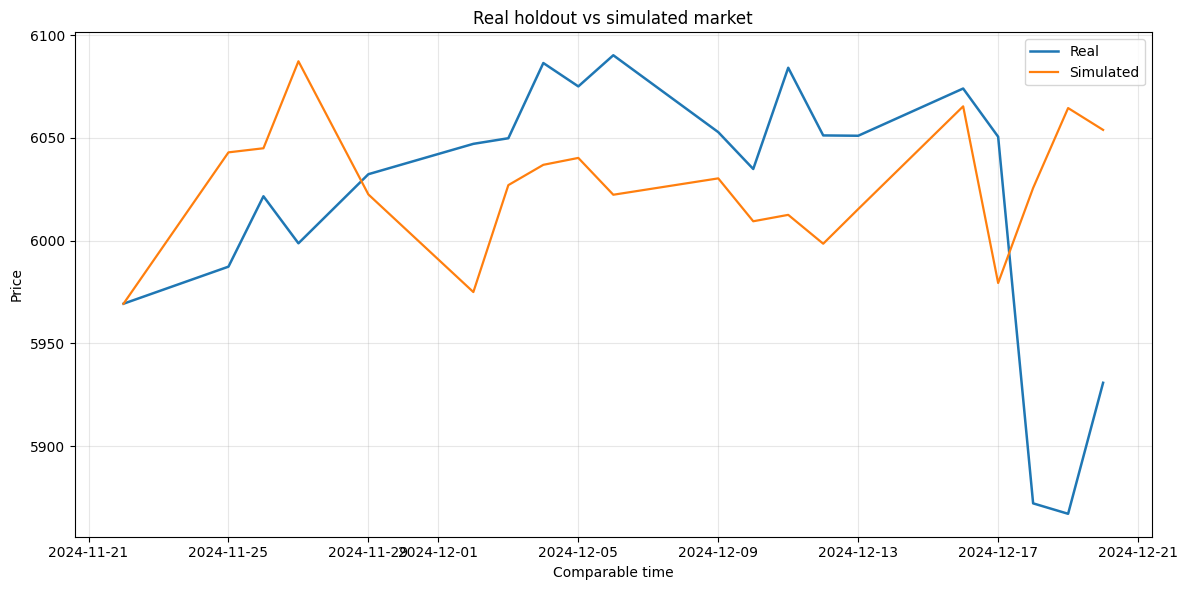

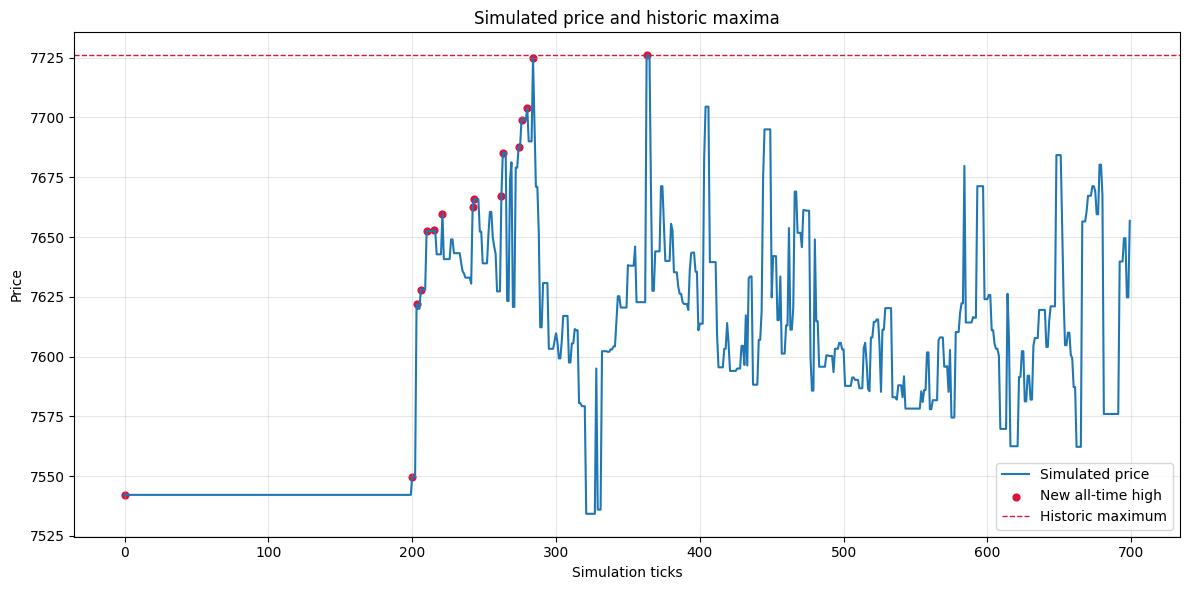

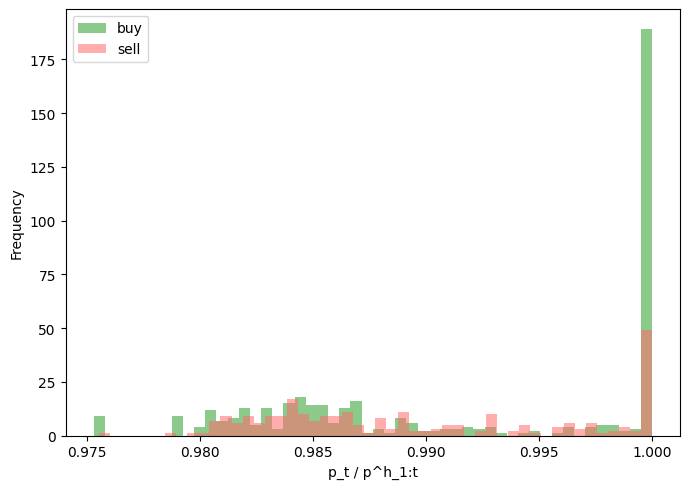

In [11]:
sa.plot_real_vs_simulated(
    llm_paper_report["real_vs_simulated"]["aligned"],
    title="Real holdout vs simulated market"
)

sa.plot_simulated_historic_maximum(
    llm_artifacts["market"],
    price_col="market_price"
)

sa.plot_all_time_high_nearness_histogram(
    llm_paper_report["order_nearness"]
)

In [12]:

sim_facts = llm_paper_report.get("sim_stylized_facts", {})
sim_facts_with_volume = llm_paper_report.get("sim_stylized_facts_with_execution_volume", sim_facts)
historic_max = llm_paper_report.get("sim_historic_maximum", {})
validation_metrics = llm_paper_report.get("validation_metrics", {})
aligned = llm_paper_report.get("real_vs_simulated", {}).get("aligned", pd.DataFrame())

distance_metrics = sa._return_distribution_distances(aligned)
macro_market_validation = sa.macro_table(sim_facts, sim_facts_with_volume, historic_max, llm_paper_report)
micro_metrics = sa._llm_order_flow_metrics(llm_artifacts, llm_paper_report)
micro_llm_validation = sa.micro_table(micro_metrics)
validation_table = sa.validation_table_func(validation_metrics, distance_metrics)
architecture_safeguard = sa.architecture_table()
real_vs_simulated_validation = sa.validation_table_func(validation_metrics, distance_metrics)

print("Macro market validation")
display(macro_market_validation)

print("Micro LLM-agent validation")
display(micro_llm_validation)

print("Real-vs-simulated validation")
display(real_vs_simulated_validation)

print("Architecture safeguard")
display(architecture_safeguard)

validation_dashboard = {
    "macro_market_validation": macro_market_validation,
    "micro_llm_validation": micro_llm_validation,
    "real_vs_simulated_validation": real_vs_simulated_validation,
    "architecture_safeguard": architecture_safeguard,
}

Macro market validation


,metric,value,principle
0,fat_tails_excess_kurtosis,12.529474,Returns in real markets usually have fat tails...
1,volatility_clustering_abs_return_autocorr_1,0.063641,Large price moves tend to cluster; positive au...
2,volatility_clustering_abs_return_autocorr_5,0.031416,Checks whether volatility persistence remains ...
3,volatility_clustering_abs_return_autocorr_10,0.069474,Checks whether volatility persistence remains ...
4,volume_volatility_correlation,0.523488,Real markets often show higher volume during m...
5,ath_path_dependence_beta_h_mse_vs_real,0.004266,Compares simulated and real beta_h; lower MSE ...
6,has_simulated_historic_maximum,True,Confirms whether the simulated path creates ne...
7,simulated_peak_price,7726.0,Maximum simulated market price reached in the ...
8,simulated_peak_tick,363.0,Artificial tick where the simulated maximum ap...


Micro LLM-agent validation


,metric,value,principle
0,llm_orders,7.000000e+02,Number of observed LLM/FCL agent orders. NaN m...
1,llm_order_flow_imbalance,2.457143e-01,(buy - sell) / total. Values near 0 mean balan...
2,ks_p_value_ath_nearness_buy_vs_sell,6.219405e-10,KS test comparing buy vs sell distributions ne...
3,mannwhitney_p_value_buy_vs_sell,5.293048e-05,Mann-Whitney U test for contextual buy/sell di...
4,portfolio_p01,3.880667e-01,1st percentile of asset allocation proportion.
5,portfolio_p50,4.031039e-01,Median asset allocation proportion.
6,portfolio_p99,4.148386e-01,99th percentile of asset allocation proportion.
7,portfolio_stability_width_p99_minus_p01,2.677186e-02,Smaller width suggests more stable portfolio a...
8,odean_proxy_pgr_minus_plr,2.608696e-02,Proxy for disposition effect. Positive means m...


Real-vs-simulated validation


,metric,value,principle
0,rmse,77.068016,Root mean squared price error between real hol...
1,nrmse_mean_price,0.012799,RMSE normalized by mean real price.
2,nrmse_price_range,0.345302,RMSE normalized by real holdout price range.
3,smape,0.009875,Symmetric percentage error; more stable than p...
4,wape,0.009853,Weighted absolute percentage error.
5,theil_u_vs_random_walk,1.584214,Below 1 beats a naive random-walk baseline; ab...
6,directional_accuracy,0.473684,Share of days/ticks where simulated and real r...
7,return_correlation,-0.193812,Correlation between real and simulated returns.
8,kl_divergence_return_distribution,16.100152,Distribution distance between real and simulat...
9,hellinger_return_distribution,0.706341,Bounded distribution distance between 0 and 1....


Architecture safeguard


,component,responsibility
0,LLM/FCL agent,Returns categorical trading intent and context...
1,Deterministic simulator,"Controls order pricing, sizing, matching, cash..."
2,Validation layer,Compares post-warmup simulated data with the r...
